# Violation of Regression Model Assumptions

Linear regression (OLS) is one of the most widely used models in data science, but it is only BLUE (Best Linear Unbiased Estimator) and produces reliable inference when five core assumptions hold. When any assumption is violated, your coefficients can become biased, inefficient, or have incorrect standard errors/p-values. A typical Python notebook on this topic systematically introduces the assumptions, shows diagnostic tools (plots + statistical tests), demonstrates violations with real/synthetic data, and discusses remedies.

### 1. The Five Classical Assumptions (OLS)

The population model is:
$$
y_i = \beta_0 + \beta_1 x_{i1} + \dots + \beta_k x_{ik} + \epsilon_i \qquad i=1,\dots,n
$$

#### Assumptions:

1. **Linearity in parameters**  
   $$
   \mathbb{E}(y \mid \mathbf{X}) = \mathbf{X}\boldsymbol{\beta}
   $$  
   (the conditional mean is linear in the parameters)

2. **Strict exogeneity / Independence**  
   $$
   \mathbb{E}(\epsilon_i \mid \mathbf{X}) = 0
   $$  
   and the errors are uncorrelated across observations

3. **Homoscedasticity**  
   $$
   \mathrm{Var}(\epsilon_i \mid \mathbf{X}) = \sigma^2
   $$  
   (constant variance of the errors given X)

4. **No perfect multicollinearity**  
   The design matrix $\mathbf{X}$ has full column rank (no perfect linear dependence among columns)

5. **Normality of errors**  
   (required only for exact finite-sample inference / t- and F-tests)  
   $$
   \epsilon_i \sim \mathcal{N}(0, \sigma^2)
   $$

In practice, we almost never observe the true errors $\epsilon_i$. Instead, we examine the **residuals**:

$$
e_i = y_i - \hat{y}_i
$$

where $\hat{y}_i$ are the fitted (predicted) values from the OLS regression.

### The Regression Model

When fitting a regression model to data, the **classical assumptions** of regression analysis must hold to ensure reliable parameter estimates and accurate inference. Ideally, we want our estimated coefficients (β̂) to be:
- **Unbiased** — their expected value (across repeated samples) equals the true population parameter  
- **Consistent** — they converge to the true value as sample size increases  
- **Efficient** — they have the smallest possible variance among all linear unbiased estimators  

In this notebook, we explore **violations** of these assumptions using simple single-variable linear regression examples. The same principles extend to multiple regression and many other models.  

**Important note**: We assume the model is **correctly specified** (i.e., the chosen functional form is appropriate). We will cover model specification errors (wrong functional form, omitted variables, etc.) — and their consequences — in a separate notebook.

### Focus on the Residuals

Instead of only examining model structure or predictors, much can be learned by studying the **residuals** (estimated errors):

$$
e_i = y_i - \hat{y}_i
$$

Even if your model becomes very complex and difficult to interpret directly, you can always compute residuals from the observed values (y) and predicted values (ŷ).Residuals are the key to diagnosing problems:  
- If they do **not** follow the expected pattern or distribution (usually normality, homoscedasticity, independence, etc.), it signals that something is wrong with the model fit or assumptions.  
- This should raise concerns about the **accuracy** and **reliability** of your predictions and inferences.

### Residuals Not Normally Distributed

One common violation occurs when the **error term (ε)** is **not normally distributed**.

**Consequences**:  
- If errors are non-normal, the usual t-tests, F-tests, and confidence intervals may be invalid in **small samples**.  
- **Fortunately**, the **Central Limit Theorem** (CLT) comes to the rescue for large samples: even if the errors themselves are not normal, the **sampling distribution of the coefficient estimates** (β̂) will still be approximately normal when the sample size is large enough.  

Therefore:  
→ For **large datasets**, non-normal residuals usually do **not** invalidate our inference about coefficients (p-values, confidence intervals remain reasonably trustworthy).  
→ For **small datasets**, non-normality can seriously affect the validity of hypothesis tests and intervals — so we must be more cautious.

In [48]:

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

from math import sqrt
from statsmodels import regression, stats
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib import pyplot as plt

### 1) Testing for Normality

**Why Test for Normality?**

One of the classical assumptions of ordinary least squares (OLS) regression is that the error terms (and therefore the residuals) are normally distributed:

$$
\epsilon_i \sim \mathcal{N}(0, \sigma^2)
$$

This assumption is required for **exact finite-sample inference** — that is, for the t-tests, F-tests, and confidence intervals to be precisely valid in small samples.

While the **Central Limit Theorem** ensures that coefficient estimates are approximately normally distributed in large samples (even if residuals are non-normal), testing for normality remains important, especially with smaller datasets.

**Testing for Normality**

**Recommended Test: Jarque-Bera**

A widely used and powerful test for normality of residuals is the **Jarque-Bera test**.

- It checks whether the skewness and kurtosis of the residuals are consistent with a normal distribution.
- The test statistic is asymptotically chi-squared distributed under the null hypothesis of normality.

Python implementation (available in `statsmodels`):

```python
from statsmodels.stats.stattools import jarque_bera

# Example usage after fitting a model
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(model.resid)

print(f"Jarque-Bera statistic: {jb_stat:.3f}")
print(f"p-value: {jb_pvalue:.4f}")
print(f"Skewness: {skew:.3f}    Kurtosis: {kurtosis:.3f}")

Jarque-Bera test p-value: 0.8760659446641594
Residuals for np.random.normal are normally distributed.
Jarque-Bera test p-value: 8.018361377675228e-49
Residuals for np.random.poisson are not normally distributed.


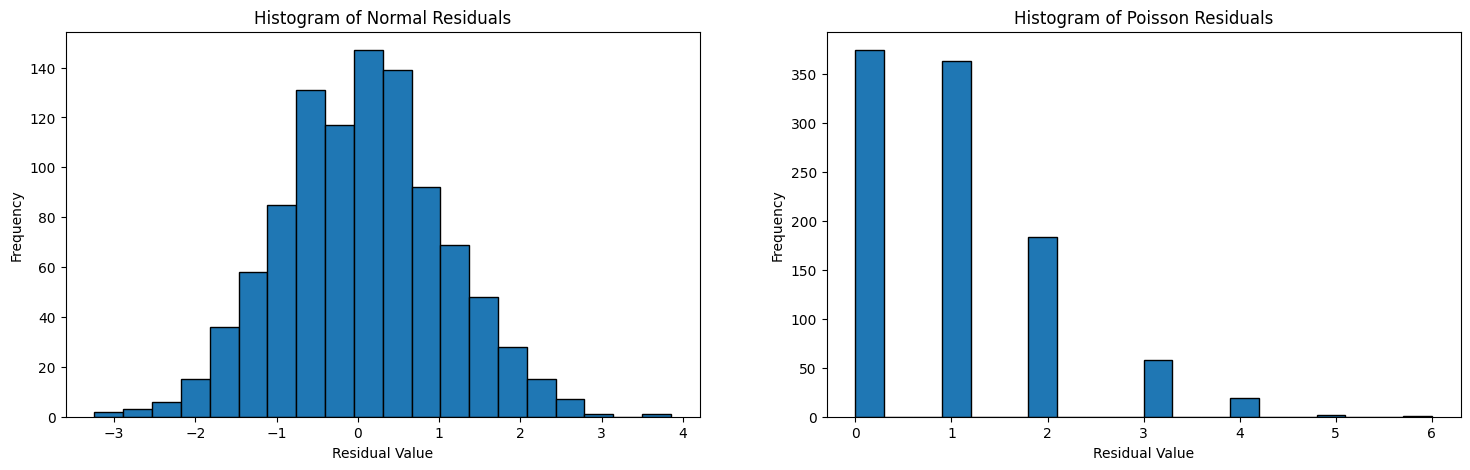

In [23]:
residuals_1 = np.random.normal(0, 1, 1000)

_, p_value, _, _ = statsmodels.stats.stattools.jarque_bera(residuals_1)
print(f"Jarque-Bera test p-value: {p_value}")
if p_value < 0.05:
  print("Residuals for np.random.normal are not normally distributed.")
else:
  print("Residuals for np.random.normal are normally distributed.")

residual_2 = np.random.poisson(size=1000)
_, p_value, _, _ = statsmodels.stats.stattools.jarque_bera(residual_2)
print(f"Jarque-Bera test p-value: {p_value}")
if p_value < 0.05:
  print("Residuals for np.random.poisson are not normally distributed.")
else:
  print("Residuals for np.random.poisson are normally distributed.")
  
# Generate a plot to visualize the distribution of the residuals
# left plot (normal distribution), right plot (poisson distribution)
plt.figure(figsize=(18, 5))

plt.subplot(1, 2, 1)
plt.hist(residuals_1, bins=20, edgecolor='k')
plt.title('Histogram of Normal Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(residual_2, bins=20, edgecolor='k')
plt.title('Histogram of Poisson Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.show()

### 2) Testing for Heteroskedasticity

**Heteroskedasticity** (or heteroscedasticity) occurs when the variance of the error terms (residuals) is **not constant** across all observations. In other words, the spread of the residuals around the regression line changes systematically — often increasing or decreasing with the level of the independent variable(s).

**Intuitive explanation**:  
The observations are **not** evenly (uniformly) scattered around the fitted regression line. This is very common in cross-sectional data, where differences in the scale or magnitude of the measured variable lead to larger errors in some regions than others (e.g., higher income → larger variability in spending).

When heteroskedasticity is present:
- OLS coefficient estimates remain **unbiased** and **consistent**, but they are no longer **efficient** (they do not have the minimum variance).
- The standard errors are biased → t-tests, p-values, and confidence intervals become unreliable.


**Homoskedastic vs. Heteroskedastic**

We generate two datasets with the **same linear trend** (`y ≈ 3x + 100`) but different error structures:

- **Homoskedastic**: constant noise (standard deviation ≈ 10 everywhere)  
- **Heteroskedastic**: noise variance **increases** with x (sd grows linearly from ~5 to ~55)

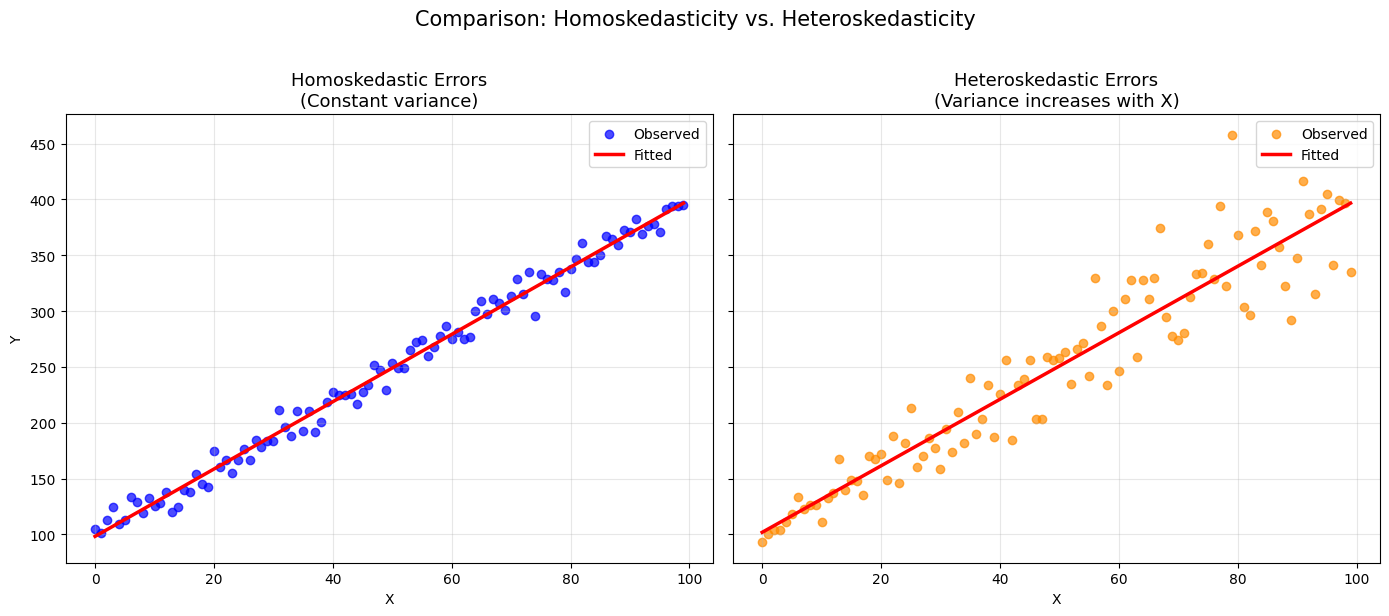

In [24]:
np.random.seed(42)           # for reproducibility
xs = np.arange(100)          # x values: 0 to 99

# ────────────────────────────────────────────────
# 1. Homoskedastic data (constant variance)
# ────────────────────────────────────────────────
yi_homo = xs * 3 + 100 + np.random.randn(100) * 10

X = sm.add_constant(xs)
model_homo = sm.OLS(yi_homo, X).fit()
intercept_h, slope_h = model_homo.params
fitted_homo = intercept_h + slope_h * xs

# ────────────────────────────────────────────────
# 2. Heteroskedastic data (variance increases with x)
# ────────────────────────────────────────────────
# Standard deviation grows linearly with x (from ~5 to ~55)
sd_hetero = 5 + 0.5 * xs
error_hetero = np.random.randn(100) * sd_hetero
yi_hetero = xs * 3 + 100 + error_hetero

model_hetero = sm.OLS(yi_hetero, X).fit()
intercept_het, slope_het = model_hetero.params
fitted_hetero = intercept_het + slope_het * xs

# ────────────────────────────────────────────────
# Plot both side-by-side
# ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Left: Homoskedastic
axes[0].scatter(xs, yi_homo, alpha=0.7, color='blue', label='Observed')
axes[0].plot(xs, fitted_homo, color='red', linewidth=2.5, label='Fitted')
axes[0].set_title('Homoskedastic Errors\n(Constant variance)', fontsize=13)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Heteroskedastic
axes[1].scatter(xs, yi_hetero, alpha=0.7, color='darkorange', label='Observed')
axes[1].plot(xs, fitted_hetero, color='red', linewidth=2.5, label='Fitted')
axes[1].set_title('Heteroskedastic Errors\n(Variance increases with X)', fontsize=13)
axes[1].set_xlabel('X')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Comparison: Homoskedasticity vs. Heteroskedasticity", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**Heteroskedasticity Test**

In [25]:
resid_1 = yi_homo - fitted_homo
resid_2 = yi_hetero - fitted_hetero

xs_with_constant = sm.add_constant(xs)

_, jb_pvalue1, _, _ = statsmodels.stats.stattools.jarque_bera(resid_1)
_, jb_pvalue2, _, _ = statsmodels.stats.stattools.jarque_bera(resid_2)

print(f"Jarque-Bera test p-value for homoskedastic residuals: {jb_pvalue1}")
print(f"Jarque-Bera test p-value for heteroskedastic residuals: {jb_pvalue2}")

_, pvalue1, _, _, = stats.diagnostic.het_breuschpagan(resid_1, xs_with_constant)
_, pvalue2, _, _, = stats.diagnostic.het_breuschpagan(resid_2, xs_with_constant)

print(f"Breusch-Pagan test p-value for homoskedastic residuals: {pvalue1}")
print(f"Breusch-Pagan test p-value for heteroskedastic residuals: {pvalue2}")

Jarque-Bera test p-value for homoskedastic residuals: 0.7719825648017324
Jarque-Bera test p-value for heteroskedastic residuals: 1.7857155743131935e-05
Breusch-Pagan test p-value for homoskedastic residuals: 0.6013945776291403
Breusch-Pagan test p-value for heteroskedastic residuals: 0.000699731465245797


#### Correcting for Heteroskedasticity

**How Does Heteroskedasticity Affect Our Analysis?**

Heteroskedasticity (especially **conditional heteroskedasticity**) occurs when the variance of the error terms is correlated with one or more independent variables — as seen in the "fan-shaped" residual patterns from earlier examples.
**Consequences**:
- OLS coefficient estimates remain **unbiased** and **consistent**.
- However, the **standard errors** are biased (usually underestimated).
- This leads to invalid **t-tests** (for individual coefficient significance) and **F-tests** (for overall model significance).
- Result: We often **overstate** statistical significance — p-values appear smaller than they should be, and confidence intervals are too narrow.

**Detecting Heteroskedasticity**

Two popular formal tests in Python (`statsmodels`):

1. **Breusch-Pagan Test**  
   Tests whether residual variance depends on the regressors.

   ```python
   from statsmodels.stats.diagnostic import het_breuschpagan

   # After fitting: model = sm.OLS(y, X).fit()
   bp_test = het_breuschpagan(model.resid, model.model.exog)
   labels = ['LM Statistic', 'LM p-value', 'F-statistic', 'F p-value']
   print(dict(zip(labels, bp_test)))

2. **White Test**
      ```python
      from statsmodels.stats.diagnostic import het_white

      white_test = het_white(model.resid, model.model.exog)
      labels = ['LM Statistic', 'LM p-value', 'F-statistic', 'F p-value']
      print(dict(zip(labels, white_test)))
      ```

In [26]:
labels = ['LM Statistic', 'LM p-value', 'F-statistic', 'F p-value']

# Breush-Pagan Test
bp_test_1 = het_breuschpagan(resid_1, xs_with_constant)
print("Breusch-Pagan Test for Homoskedastic Residuals (Resid 1):")
print(dict(zip(labels, bp_test_1)))

bp_test_2 = het_breuschpagan(resid_2, xs_with_constant)
print("\nBreusch-Pagan Test for Heteroskedastic Residuals (Resid 2):")
print(dict(zip(labels, bp_test_2))) 
  
# White Test
white_test_1 = het_white(resid_1, xs_with_constant)
print("White Test for Homoskedastic Residuals:")
print(dict(zip(labels, white_test_1)))

white_test_2 = het_white(resid_2, xs_with_constant)
print("\nWhite Test for Heteroskedastic Residuals:")
print(dict(zip(labels, white_test_2)))

Breusch-Pagan Test for Homoskedastic Residuals (Resid 1):
{'LM Statistic': 0.2728976751265044, 'LM p-value': 0.6013945776291403, 'F-statistic': 0.268171555564464, 'F p-value': 0.6057280388642077}

Breusch-Pagan Test for Heteroskedastic Residuals (Resid 2):
{'LM Statistic': 11.489959900268676, 'LM p-value': 0.000699731465245797, 'F-statistic': 12.721902158868737, 'F p-value': 0.0005610198362551729}
White Test for Homoskedastic Residuals:
{'LM Statistic': 0.8099006002616815, 'LM p-value': 0.6670099603424621, 'F-statistic': 0.3960090709697913, 'F p-value': 0.6740836377611886}

White Test for Heteroskedastic Residuals:
{'LM Statistic': 11.497061064060187, 'LM p-value': 0.00318746122897595, 'F-statistic': 6.300440056691526, 'F p-value': 0.00267576576802781}


### 3) Serial Correlation (Autocorrelation) of Errors

**What Is Serial Correlation?**

A common and serious violation of regression assumptions occurs when the error terms (residuals) are **correlated across observations** — known as **serial correlation**, **autocorrelation**, or **temporal dependence** This problem frequently arises in:
- **Time-series data** with trends, cycles, seasonality, or persistence
- Datasets where observations are naturally related (e.g., spatial data, repeated measures)
- Models with **lagged dependent variables** or **omitted relevant variables** that induce correlation in residuals

**Consequences**:
- If autocorrelation is present **and** the model is misspecified (e.g., missing lagged terms), coefficient estimates become **biased** and **inconsistent**.
- Even if coefficients remain consistent (common in many cases), the **standard errors** are biased (usually underestimated).
- This leads to invalid **t-tests**, **F-tests**, and confidence intervals — we often **overstate** statistical significance and appear to have a better fit than actually exists.

**Detecting Autocorrelation: Durbin-Watson Test**

Assuming the errors are homoskedastic, the **Durbin-Watson (DW) test** is a standard way to check for first-order autocorrelation (AR(1)). The test statistic is:

$$
DW = \frac{\sum_{t=2}^T (e_t - e_{t-1})^2}{\sum_{t=1}^T e_t^2} \approx 2(1 - \hat{\rho})
$$

where $\hat{\rho}$ is the sample autocorrelation of the residuals.

**Interpretation guidelines**:
- DW ≈ **2** → no first-order autocorrelation (ideal)
- DW < 2 (especially < 1.5) → **positive** autocorrelation (most common in time series)
- DW > 2 (especially > 2.5) → **negative** autocorrelation

In `statsmodels`, the DW statistic is **automatically reported** in the model summary:

```python
import statsmodels.api as sm

# After fitting your model
model = sm.OLS(y, X).fit()
print(model.summary())          # Look for "Durbin-Watson:" near the bottom

[*********************100%***********************]  1 of 1 completed


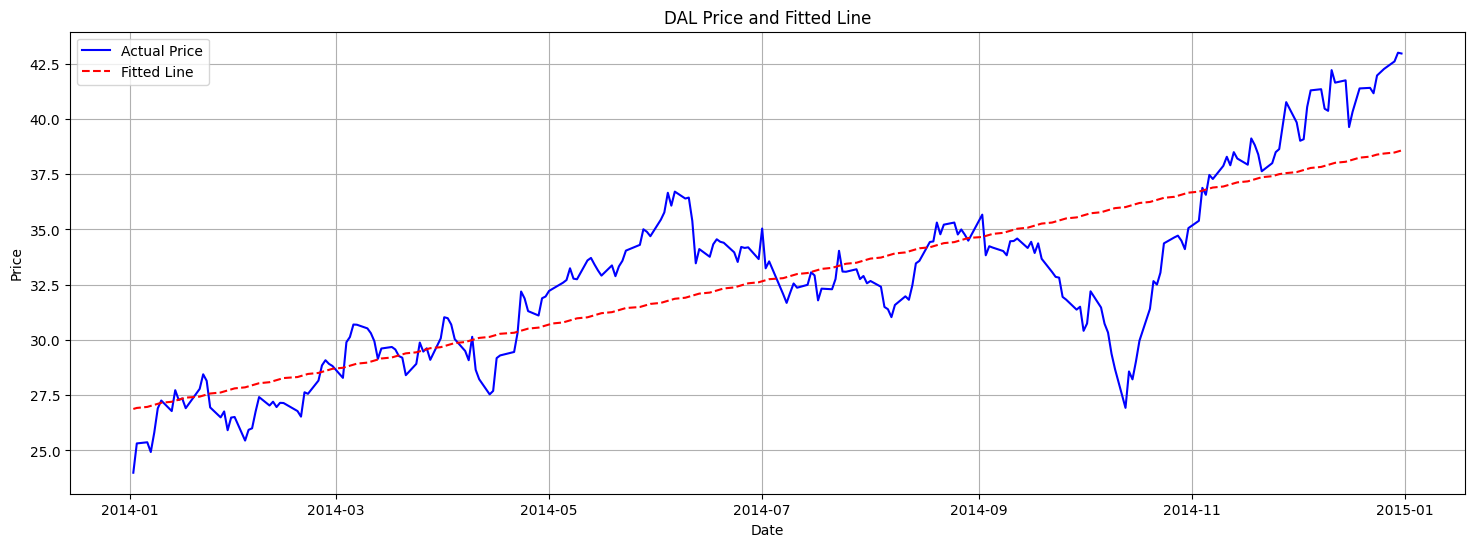

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.669
Method:                 Least Squares   F-statistic:                     507.7
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           3.93e-62
Time:                        22:56:51   Log-Likelihood:                -575.90
No. Observations:                 252   AIC:                             1156.
Df Residuals:                     250   BIC:                             1163.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.8774      0.300     89.609      0.0

In [28]:
# Loading the price of an asset
start_date = '2014-01-01'
end_date = '2015-01-01'
ticker = 'DAL'

close_data = yf.download(ticker, start=start_date, end=end_date)['Close']
X = np.arange(len(close_data))

# Regress pricing data against time
model = sm.OLS(close_data.values, sm.add_constant(X)).fit()
residuals = model.resid

prediction = model.params[0] + model.params[1] * X

# Plot the price data and the fitted line
plt.figure(figsize=(18, 6))
plt.plot(close_data.index, close_data.values, label='Actual Price', color='blue')
plt.plot(close_data.index, prediction, label='Fitted Line', color='red', linestyle='--')
plt.title(f'{ticker} Price and Fitted Line')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Print the mpdel summary
print(model.summary())

### Testing for Autocorrelation

**Why Test for Autocorrelation in Prices and Residuals?**

In time-series regression (or when analyzing any ordered data), we must check whether residuals — or the original series itself — exhibit **autocorrelation** (serial correlation). Significant autocorrelation violates the independence assumption and can invalidate inference. A powerful and commonly used test is the **Ljung-Box test** (also called the Ljung-Box Q-test).

#### Ljung-Box test

It checks whether a series (or its residuals) has significant autocorrelation up to a specified lag.
- **Null hypothesis (H₀)**: No autocorrelation at lags 1 through h (the series is independently distributed).  
- **Alternative**: At least one lag shows significant autocorrelation.

The test is based on the sample autocorrelations and is asymptotically chi-squared distributed.

In [33]:
_, prices_qstats, prices_qstat_values = statsmodels.tsa.stattools.acf(close_data, qstat=True)
_, prices_qstats, prices_qstat_values_residuals = statsmodels.tsa.stattools.acf(close_data[ticker] - prediction, qstat=True)

print("Prices autocorrelation p-values:", prices_qstat_values)
print("Residuals autocorrelation p-values:", prices_qstat_values_residuals)

_, jb_pvalues, _, _ = statsmodels.stats.stattools.jarque_bera(close_data[ticker] - prediction)

print(f"Jarque-Bera test p-value for residuals: {jb_pvalues}")

Prices autocorrelation p-values: [1.40792558e-053 8.18605966e-101 5.25038478e-145 2.10699257e-186
 3.60843447e-225 1.93175933e-261 2.00437490e-295 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000]
Residuals autocorrelation p-values: [8.84141693e-052 5.65414023e-096 9.54965201e-136 8.25096685e-172
 3.49553782e-204 1.31957384e-232 1.14538115e-257 9.32140089e-280
 1.87469000e-299 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000]
Jarque-Bera test p-value for residuals: 1.9415461264165028e-10


As we can see from the abpve results, all the p-values are very low, signifying autocorrelation is present in both the actual and predicted prices

#### Newey-West Standard Errors

**Why Use Newey-West?**

**Newey-West** is a robust method for estimating the covariance matrix of regression coefficients when residuals exhibit **autocorrelation** (and possibly heteroskedasticity). A standard (naive) OLS variance-covariance matrix assumes no serial correlation. If positive autocorrelation is present — very common in time-series or ordered data — the usual standard errors are **underestimated**. This leads to:
- Inflated t-statistics
- Overly small p-values
- Overstated statistical significance

The Newey-West estimator (also called HAC — Heteroskedasticity and Autocorrelation Consistent) corrects for both heteroskedasticity and autocorrelation up to a specified lag, producing **reliable standard errors** without needing to respecify the model (e.g., no need to add lags manually in many cases).

**Implementation in statsmodels**

We use `statsmodels.stats.sandwich_covariance.cov_hac` (or the convenience method `get_robustcov_results`) to compute Newey-West adjusted standard errors.

In [36]:
cov_mat = stats.sandwich_covariance.cov_hac(model)

# Print the standard errors from the original model and the robust standard errors
print("Original standard errors:", model.bse[0], model.bse[1])
print("Adjusted standard errors:", sqrt(cov_mat[0,0]), sqrt(cov_mat[1,1]))

Original standard errors: 0.29994119131051794 0.0020677159793481463
Adjusted standard errors: 0.4419977545386719 0.004477113340820243


### 4) Multicollinearity

**What Is Multicollinearity?**

When a regression model includes **multiple independent variables**, we must check for **multicollinearity** — a situation where two or more predictors are highly (approximately) linearly related.

**Example**:
$$
X_2 \approx 5X_1 - X_3 + 4.5
$$

In other words, one variable can be (almost) perfectly predicted from a linear combination of the others.

**Consequences**:
- Coefficient estimates remain **unbiased** and the model can still have a high R² (good overall fit).
- However, **standard errors** of the coefficients become very large → t-statistics become small → p-values become large → individual coefficients appear statistically insignificant even when they should be important.
- It becomes difficult (or impossible) to isolate the **independent effect** of each variable: changing one predictor while holding others constant is not realistic when they move together.
- Coefficients become unstable — small changes in data or model specification can cause large swings in estimates (sign flips, magnitude changes).

**Key intuition**: Multicollinearity does **not** hurt the model's predictive power, but it severely clouds **interpretation** and **inference** about partial effects.

**Detecting Multicollinearity**

1. **Simple correlation matrix** — look for pairwise correlations > |0.8| or |0.9|
2. **Variance Inflation Factor (VIF)** — the gold-standard diagnostic  
   VIF measures how much the variance of a coefficient is inflated due to correlation with other predictors.
   - VIF = 1 → no multicollinearity  
   - VIF > 5 (or > 10, depending on strictness) → problematic multicollinearity  
   - Rule of thumb: VIF > 5–10 signals serious issues for that variable

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

R-squared:  0.9032463639746221
Adjusted R-squared:  0.902469226335864

 t-statistics of coefficients:
 const   -11.782190
x1       23.780496
x2       -4.501902
dtype: float64


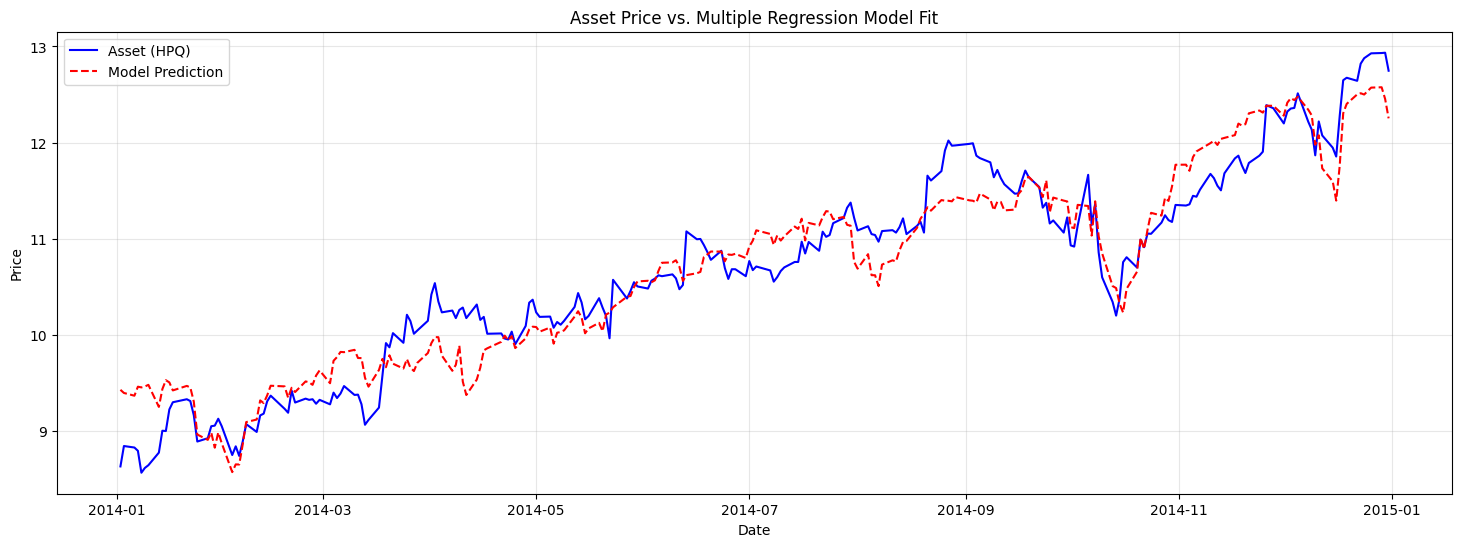

In [ ]:
# Define date range
start_date = '2014-01-01'
end_date   = '2015-01-01'

# Load pricing data for asset and two market indices
b1 = yf.download('SPY', start=start_date, end=end_date)['Close']
a = yf.download('HPQ', start=start_date, end=end_date)['Close']
b2 = yf.download('MDY', start=start_date, end=end_date)['Close']

# Run multiple linear regression: HPQ ~ SPY + MDY
# Stack the two independent variables horizontally
X = np.column_stack((b1, b2))
X = sm.add_constant(X)                # add intercept
mlr = regression.linear_model.OLS(a, X).fit()

# Construct fitted (predicted) values using coefficients
mlr_prediction = mlr.params[0] + mlr.params[1]*b1['SPY'] + mlr.params[2]*b2['MDY']

# Print regression statistics
print("R-squared: ", mlr.rsquared)
print("Adjusted R-squared: ", mlr.rsquared_adj)
print("\n t-statistics of coefficients:\n", mlr.tvalues)

# Plot actual asset prices vs model prediction
plt.figure(figsize=(18, 6))
plt.plot(a.index, a.values, label='Asset (HPQ)', color='blue')
plt.plot(a.index, mlr_prediction.values, label='Model Prediction', color='red', linestyle='--')
plt.title('Asset Price vs. Multiple Regression Model Fit')
plt.legend()
plt.ylabel('Price')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.show()

**Detecting Multicollinearity**

As mentioned above:
1. **Simple correlation matrix** — look for pairwise correlations > |0.8| or |0.9|
2. **Variance Inflation Factor (VIF)** — the gold-standard diagnostic  
   VIF measures how much the variance of a coefficient is inflated due to correlation with other predictors.

   - VIF = 1 → no multicollinearity  
   - VIF > 5 (or > 10, depending on strictness) → problematic multicollinearity  
   - Rule of thumb: VIF > 5–10 signals serious issues for that variable


**Sample Output:**
```python
Variance Inflation Factors (VIF):
  Variable     VIF
0    const   123.45   # intercept often high — ignore
1      SPY   45.67    # very high → strong multicollinearity!
2      MDY   45.89    # very high → same issue
```

In [51]:
def detect_multicollinearity(tickers, start_date, end_date):
  # Load pricing data for each ticker
  data = yf.download(tickers, start=start_date, end=end_date)['Close']
  data = data.dropna()  # Drop rows with missing values
  
  a = data[tickers[0]]  # Dependent variable (first ticker)
  b1 = data[tickers[1]] # Independent variables (other tickers)
  b2 = data[tickers[2]]
  X = pd.DataFrame({
    'SPY': b1,
    'MDY': b2
  })
  X = sm.add_constant(X)  # Add intercept term
  
  # Compute VIF for each
  vif_data = pd.DataFrame()
  vif_data["Variable"] = X.columns
  vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

  print("Variance Inflation Factors (VIF):")
  print(vif_data.round(2))
  
  # VIF > 5–10 usually indicates problematic multicollinearity
  if vif_data['VIF'][1] > 5 or vif_data['VIF'][2] > 5:
    print("\nWarning: High VIF values indicate potential multicollinearity issues.")
  else:
    print("\nVIF values are within acceptable range, no severe multicollinearity detected.")

In [52]:
start_date = '2014-01-01'
end_date   = '2015-01-01'
tickers = ['HPQ', 'SPY', 'MDY']
detect_multicollinearity(tickers, start_date, end_date)

[**********************67%*******                ]  2 of 3 completed

[*********************100%***********************]  3 of 3 completed

Variance Inflation Factors (VIF):
  Variable      VIF
0    const  1154.83
1      SPY     5.95
2      MDY     5.95

